In [475]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [476]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

from Bio import Phylo
from Bio import AlignIO
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

# 1. Generating alignment

In [477]:
# Reading in full sequences
nac_seqs = pd.read_csv("../data/nac_family.csv", sep = "\t", header = None)
nac_seqs["name"] = "NAC" + nac_seqs[0].str.split("|").str[0]
nac_seqs

,0,1,name
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076


In [478]:
# Add SOG1
wt_seq = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
wt_seq

'MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKAYSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCKKIMVLYGGKAVKTNWVMHQYHLGIEEDEKEGDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICSDSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD'

In [479]:
nac_seqs.loc[15] = ["008|Q6NQK2|", wt_seq, "SOG1"]
nac_seqs

,0,1,name
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076


In [480]:
# Preparing to align
protfasta.write_fasta(dict(zip(nac_seqs["name"], nac_seqs[1])), "../data/nac_seqs.fasta")

In [481]:
! mafft --auto --quiet ../data/nac_seqs.fasta > ../data/nac_seqs_aligned.fasta

python(24501) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [482]:
#! FastTree ../data/nac_seqs_aligned.fasta > ../data/nac_seqs_aligned

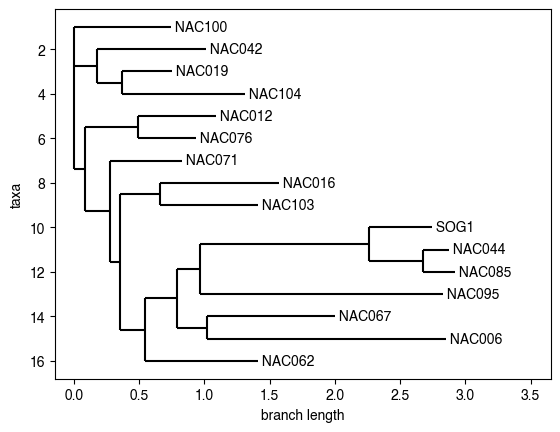

In [483]:
AD_tree = Phylo.read("../data/nac_seqs_aligned", "newick")
Phylo.draw(AD_tree, do_show=False, show_confidence=False)  # Pass axes to the draw function

In [484]:
alignment = AlignIO.read("../data/nac_seqs_aligned.fasta", "fasta")
print(alignment)

Alignment with 16 rows and 757 columns
--------------------------------------------...--- NAC006
MA------------------------------------------...--- NAC012
MV------------------------------------------...LLS NAC016
MG------------------------------------------...--- NAC019
MSG-----------------------------------------...--- NAC042
MA---RAWIVDGRGIAAKVKNASLSSALQ--IQDCGAHIKCPNC...--- NAC044
MN------------------------------------------...AVS NAC062
M-------------------------------------------...--- NAC067
--------------------------------------------...--- NAC071
ME------------------------------------------...LHV NAC076
MKTLHRTWIVDGPWISRNVKNASLSSALQ--IKDCGAYINCFNC...--- NAC085
MG------------------------------------------...--- NAC095
ME------------------------------------------...--- NAC100
--------------------------------------------...--- NAC103
--------------------------------------------...--- NAC104
MAG--RSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKC...--- SOG1


# 2. Reading in activities

In [485]:
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["search_term"] = basic_tiles["Description"].str.split(".").str[0] + "\."
basic_tiles

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,search_term
0,1,40,Basic6.1,Q9LR74,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,2368.033596,1588.671301,1978.352449,Q9LR74,Basic6\.
1,11,50,Basic6.2,Q9LR74,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,2658.783784,2465.800820,2562.292302,Q9LR74,Basic6\.
2,21,60,Basic6.3,Q9LR74,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,2659.110463,NaN,2659.110463,Q9LR74,Basic6\.
3,31,70,Basic6.4,Q9LR74,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,2481.879873,953.866893,1717.873383,Q9LR74,Basic6\.
4,41,80,Basic6.5,Q9LR74,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,2141.755789,1746.148675,1943.952232,Q9LR74,Basic6\.
...,...,...,...,...,...,...,...,...,...,...
3012,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,436.930537,3391.437462,1914.184000,Q6NQK2,BasicArTh\.
3013,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,625.828688,1279.408756,952.618722,Q6NQK2,BasicArTh\.
3014,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,2158.626634,1035.676065,1597.151349,Q6NQK2,BasicArTh\.
3015,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2202.825783,2314.580013,2258.702898,Q6NQK2,BasicArTh\.


In [486]:
nac_seqs["uniprotID"] = nac_seqs[0].str.split("|").str[1]
nac_seqs

,0,1,name,uniprotID
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508


In [487]:
nac_seqs = pd.merge(nac_seqs, basic_tiles[["Other", "search_term"]].drop_duplicates(), left_on = "uniprotID", right_on = "Other")
nac_seqs

,0,1,name,uniprotID,Other,search_term
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74,Q9LR74,Basic6\.
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7,Q9LPI7,Basic12\.
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP,A4FVP,Basic16\.
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932,Q9C932,Basic19\.
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55,Q9SK55,Basic42\.
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5,F4J4R5,Basic44\.
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6,Q9SCK6,Basic62\.
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593,O82593,Basic67\.
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697,O49697,Basic71\.
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508,O65508,Basic76\.


In [488]:
activity_dict = {}
for i in nac_seqs.index:
    activities = list(sog1_helpers.return_avg_activities(nac_seqs["search_term"].iloc[i], pos_regex = r'\.(\d+)')["smoothed_avg_activity"])
    activity_dict[nac_seqs["name"].iloc[i]] = activities

In [489]:
"hi"[:-1]

'h'

In [490]:
# Checking whether the sequence lengths == Activity lengths

ids = []
activities_aligned = []

for record in alignment:
    ids.append(record.id)
    one_tf_aligned_activities = []
    unaligned_activities = activity_dict[record.id]
    seq = record.seq

    if len(unaligned_activities) != len(str(seq).replace("-", "")):
        print(record.id)
        print(len(str(seq).replace("-", "")))
        print(len(unaligned_activities))
        

NAC085
361
350


In [491]:
sog1_helpers.return_avg_activities("Basic85\.", pos_regex = r'\.(\d+)')

,range,Activity_S3_1,smoothed_avg_activity
0,1,376.051558,376.085432
1,2,376.051558,376.133749
2,3,376.051558,376.271452
3,4,376.051558,376.592069
4,5,376.051558,377.252220
...,...,...,...
345,346,740.478947,737.161783
346,347,740.478947,738.985634
347,348,740.478947,739.871428
348,349,740.478947,740.251871


In [492]:
sog1_helpers.return_activities("Basic85\.", pos_regex = r'\.(\d+)')

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1,40,Basic85.1,A0A1P8BAI4,21,MKTLHRTWIVDGPWISRNVKNASLSSALQIKDCGAYINCF,376.051558,NaN,376.051558
1,11,50,Basic85.2,A0A1P8BAI4,31,DGPWISRNVKNASLSSALQIKDCGAYINCFNCSYRIDNSN,449.411904,NaN,449.411904
2,21,60,Basic85.3,A0A1P8BAI4,41,NASLSSALQIKDCGAYINCFNCSYRIDNSNVLTPWPGLPK,755.324399,NaN,755.324399
3,31,70,Basic85.4,A0A1P8BAI4,51,KDCGAYINCFNCSYRIDNSNVLTPWPGLPKGVKFEPTDEE,461.037386,NaN,461.037386
4,41,80,Basic85.5,A0A1P8BAI4,61,NCSYRIDNSNVLTPWPGLPKGVKFEPTDEEVIEHLEAKCG,646.366476,NaN,646.366476
5,51,90,Basic85.6,A0A1P8BAI4,71,VLTPWPGLPKGVKFEPTDEEVIEHLEAKCGIDGLKPHLLI,396.572970,NaN,396.572970
6,61,100,Basic85.7,A0A1P8BAI4,81,GVKFEPTDEEVIEHLEAKCGIDGLKPHLLIQDFICSVTQD,589.355522,NaN,589.355522
7,71,110,Basic85.8,A0A1P8BAI4,91,VIEHLEAKCGIDGLKPHLLIQDFICSVTQDVGINYTHPQN,763.599729,NaN,763.599729
8,81,120,Basic85.9,A0A1P8BAI4,101,IDGLKPHLLIQDFICSVTQDVGINYTHPQNLPGVSKDGTS,517.980538,NaN,517.980538
9,91,130,Basic85.10,A0A1P8BAI4,111,QDFICSVTQDVGINYTHPQNLPGVSKDGTSVFFFNKTAHA,574.929560,NaN,574.929560


In [493]:
# BLAST OF last tile
# Actually uniprotID A0A1P8BAI8, not A0A1P8BAI4

# Uniprot entry goes until 347
# Seems like last tile's coordinates should actually be from 337-347!

In [494]:
ids = []
activities_aligned = []

for record in alignment:
    one_tf_aligned_activities = []
    unaligned_activities = activity_dict[record.id]
    seq = record.seq
    ids.append(record.id)
    
    if len(unaligned_activities) != len(str(seq).replace("-", "")):
        print(record.id)
        print(len(str(seq).replace("-", "")))
        print(len(unaligned_activities))
        activities_aligned.append(np.full(shape=len(seq), fill_value=None))
    else:
        

        i = 0
        for AA in str(seq):
            #if i < len(unaligned_activities):
            if AA != "-":
                one_tf_aligned_activities.append(unaligned_activities[i])
                i += 1
            else:
                one_tf_aligned_activities.append(np.nan)
            # else:
            #     i += 1
            #     one_tf_aligned_activities.append(np.nan)
            #     print("ERROR BEYOND LENGTH OF " + record.id)
            #     print(i)
            
        activities_aligned.append(one_tf_aligned_activities)

NAC085
361
350


In [495]:
activities_aligned_df = pd.DataFrame(activities_aligned)
activities_aligned_df["name"] = ids
activities_aligned_df = activities_aligned_df.set_index("name")
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,1928.871186,1927.999591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,5054.991263,5051.875106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1556.505457,1481.508404,1403.837784,1333.537561,1280.414340,1251.904676
NAC019,1321.536743,1321.935229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,2132.062898,2132.062898,2132.062898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,264.643240,264.725365,NaN,NaN,NaN,264.959424,265.504390,266.626476,268.693894,272.102490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,730.3799,647.499475,569.049761,502.630084,452.314502,418.210119,397.524766,386.325671,380.972938,378.923951
NAC067,1230.576463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [496]:
activities_aligned_df.notna().sum(axis = 1).sort_values()

name
NAC085      0
NAC104    187
NAC095    212
NAC071    262
NAC067    268
NAC042    275
NAC006    281
NAC019    317
NAC100    336
NAC103    356
NAC012    358
NAC044    366
NAC076    377
NAC062    447
SOG1      449
NAC016    564
dtype: int64

In [497]:
name_order = []
for entry in AD_tree.get_terminals():
   name_order.append(entry.name)
name_order

['NAC100',
 'NAC042',
 'NAC019',
 'NAC104',
 'NAC012',
 'NAC076',
 'NAC071',
 'NAC016',
 'NAC103',
 'SOG1',
 'NAC044',
 'NAC085',
 'NAC095',
 'NAC067',
 'NAC006',
 'NAC062']

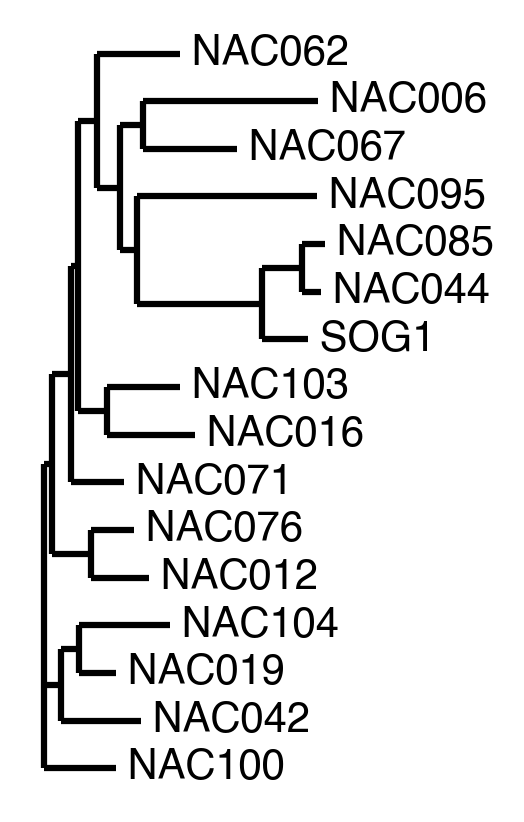

In [498]:
plot_next_to_tree(AD_tree)

In [499]:
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,1928.871186,1927.999591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,5054.991263,5051.875106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1556.505457,1481.508404,1403.837784,1333.537561,1280.414340,1251.904676
NAC019,1321.536743,1321.935229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,2132.062898,2132.062898,2132.062898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,264.643240,264.725365,NaN,NaN,NaN,264.959424,265.504390,266.626476,268.693894,272.102490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,730.3799,647.499475,569.049761,502.630084,452.314502,418.210119,397.524766,386.325671,380.972938,378.923951
NAC067,1230.576463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [500]:
activities_aligned_df_normalized = activities_aligned_df / activities_aligned_df.max(numeric_only=True).max()
activities_aligned_df_normalized

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,0.381578,0.381405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,1.000000,0.999384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.307915,0.293078,0.277713,0.263806,0.253297,0.247657
NAC019,0.261432,0.261511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,0.421774,0.421774,0.421774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,0.052353,0.052369,NaN,NaN,NaN,0.052415,0.052523,0.052745,0.053154,0.053828,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.144487,0.128091,0.112572,0.099432,0.089479,0.082732,0.078640,0.076425,0.075366,0.074960
NAC067,0.243438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


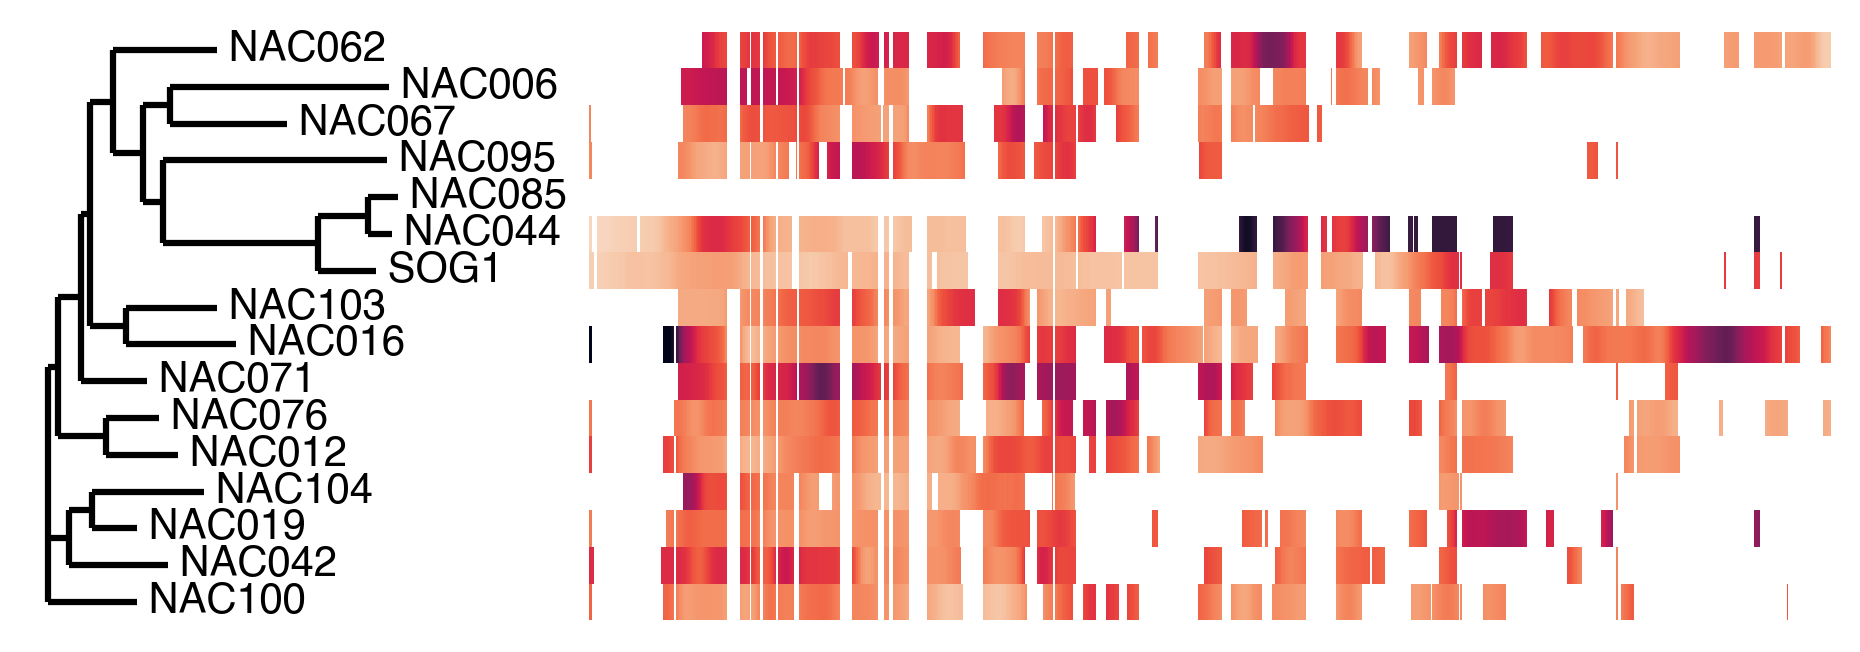

In [501]:
fig = plt.figure(figsize=(6,2), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)


for i in np.arange(16):
    label = name_order[len(name_order) - 1 -i]
    ax_i = fig.add_subplot(spec[i, 1])
    ax_i.imshow([activities_aligned_df_normalized.loc[label]], 
                aspect="auto", interpolation="none", 
                extent=[0, 757, 0, 1], 
                cmap = "rocket_r", 
                vmin = 0, 
                vmax = 0.95)
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_ylabel("")

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)
plt.savefig("../output/figures/conservation/nac_family/full_aligned.png", bbox_inches='tight')


# 3. Only aligning on DBD

In [502]:
nac_seqs["DBD_seq"] = nac_seqs[1].str.extract("(G..F.P)")
nac_seqs["DBD_pos"] = [seq.find(pat) for seq, pat in zip(nac_seqs[1], nac_seqs["DBD_seq"])]
nac_seqs["len_past_dom"] = nac_seqs[1].str.len() - nac_seqs["DBD_pos"]
#nac_seqs["len_pre_dom"] = 
nac_seqs["len"] = nac_seqs[1].str.len()
nac_seqs

,0,1,name,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593,O82593,Basic67\.,GYRFSP,6,296,302
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697,O49697,Basic71\.,GFRFHP,8,254,262
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508,O65508,Basic76\.,GFRFHP,12,365,377


In [503]:
# One with 60 residues prior to DBD
max(nac_seqs["DBD_pos"])

60

In [504]:
# One with 546 residues post DBD
max(nac_seqs["len_past_dom"])

546

In [505]:
# Num positions
60 + 546

606

In [506]:
pd.DataFrame(activity_dict["SOG1"]).T

,0,1,2,3,4,5,6,7,8,9,...,439,440,441,442,443,444,445,446,447,448
0,346.281681,346.381022,346.664149,347.32336,348.680676,351.181501,355.304664,361.387733,369.423354,378.927865,...,2030.791298,2014.817217,1999.714629,1986.932861,1977.251972,1970.690173,1966.710241,1964.555497,1963.525613,1963.131381


In [507]:
activity_dict_normalized = {}
for key in activity_dict.keys():
    activity_dict_normalized[key] = np.array(activity_dict[key]) / activities_aligned_df.max(numeric_only=True).max()

(-60.0, 546.0)

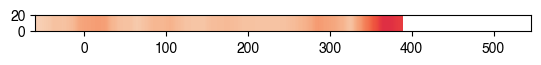

In [508]:
plt.imshow(pd.DataFrame(activity_dict_normalized["SOG1"]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [-60, 389, 0, 20])
plt.xlim(-60, 546)

In [509]:
nac_seqs = nac_seqs.set_index("name")
nac_seqs

,0,1,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
name,,,,,,,,,
NAC006,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
NAC012,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
NAC016,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
NAC019,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
NAC042,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
NAC044,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
NAC062,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
NAC067,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,O82593,O82593,Basic67\.,GYRFSP,6,296,302
NAC071,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,O49697,O49697,Basic71\.,GFRFHP,8,254,262


In [510]:
nac_seqs.sort_values(by = "len_past_dom", ascending = False)

,0,1,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
name,,,,,,,,,
NAC016,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
NAC062,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
SOG1,008|Q6NQK2|,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,Q6NQK2,Q6NQK2,BasicArTh\.,GVKFDP,60,389,449
NAC076,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,O65508,O65508,Basic76\.,GFRFHP,12,365,377
NAC103,103|Q9FMJ1|,MGKTNLAPGFRFHPTDVELVRYYLKRKVMGKKFQVDAIAEVDIYKF...,Q9FMJ1,Q9FMJ1,Basic103\.,GFRFHP,8,348,356
NAC012,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
NAC100,100|Q9FLJ2|,METFCGFQKEEEQMDLPPGFRFHPTDEELITHYLHKKVLDTSFSAK...,Q9FLJ2,Q9FLJ2,Basic100\.,GFRFHP,18,318,336
NAC044,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
NAC019,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317


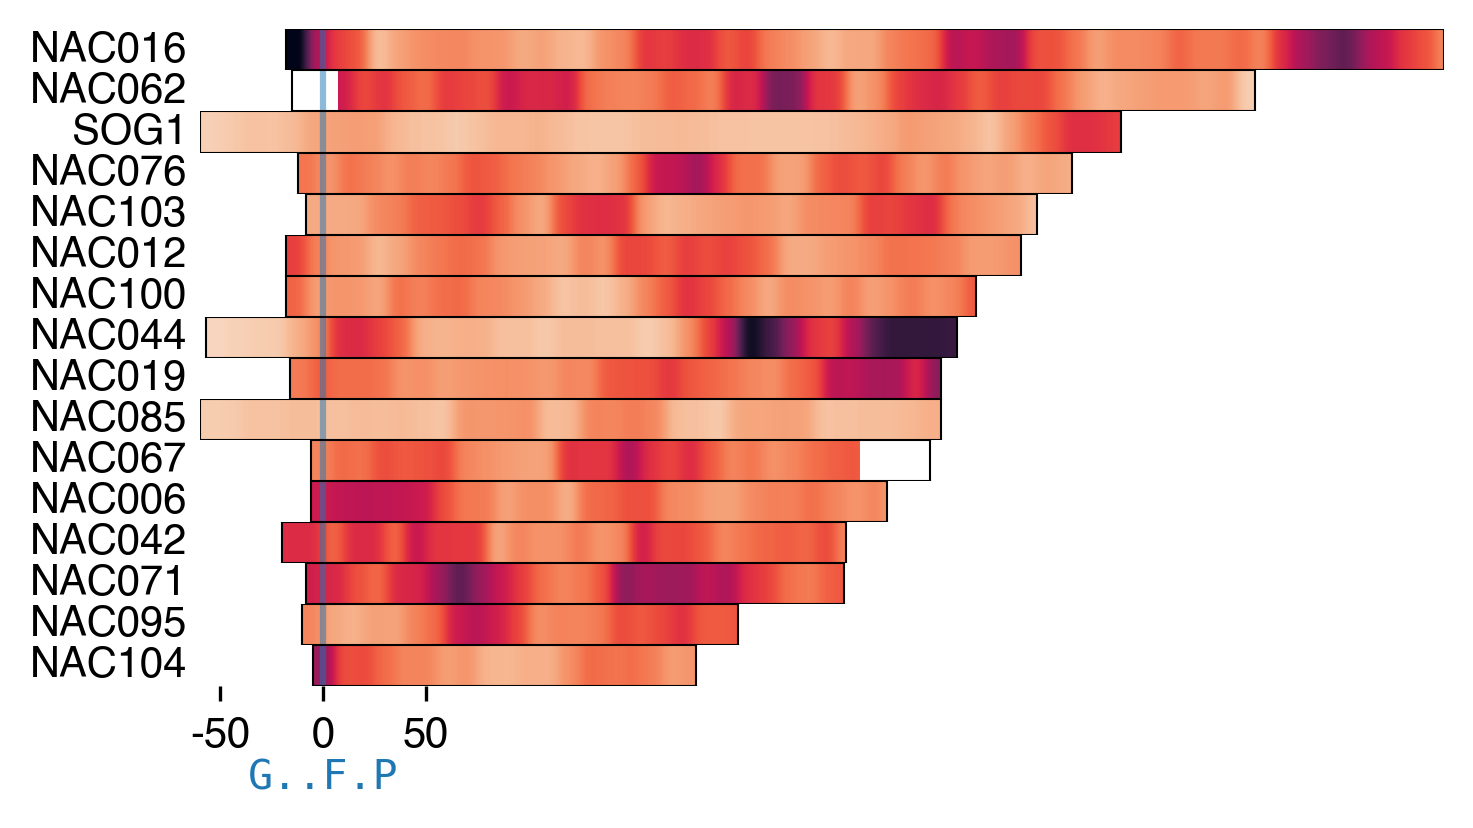

In [512]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

i = 0

for name in nac_seqs.sort_values(by = "len_past_dom", ascending = False).index:
    start = -1 * nac_seqs["DBD_pos"].loc[name]
    end = nac_seqs["len_past_dom"].loc[name]

    axs[i].imshow(pd.DataFrame(activity_dict_normalized[name]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [start, end, 0, 20])
    axs[i].set_xlim(-60, 546)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].axvline(0, alpha = 0.5)
    axs[i].set_ylabel(name, rotation = 0, va = 'center', labelpad = 3, ha = "right")
    
    axs[i].axvline(start, color = "black", lw = 0.5)
    axs[i].axvline(end, color = "black", lw = 0.5)

    axs[i].plot((start, end), (20, 20), 'k-',linewidth=0.5)
    axs[i].plot((start, end), (0, 0), 'k-',linewidth=0.5)

    i += 1
    
axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

In [513]:
def return_positions(string, substring):
    def return_positions_helper(string, substring, pos, positions):
        window_size = len(substring)
        if len(string) == 0:
            return positions
        if string[:window_size] == substring:
            positions.append(pos)
            string = string[window_size:]
            pos += window_size - 1
        else:
            string = string[1:]
            
        return return_positions_helper(string, substring, pos + 1, positions)

    return return_positions_helper(string, substring, 1, [])

def return_positions_multip_strs(string, substring1, substring2):
    matches_1 = return_positions(string, substring1)
    matches_2 = return_positions(string, substring2)
    return list(set(matches_1).union(set(matches_2)))

In [514]:
nac_seqs

,0,1,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
name,,,,,,,,,
NAC006,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
NAC012,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
NAC016,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
NAC019,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
NAC042,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
NAC044,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
NAC062,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
NAC067,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,O82593,O82593,Basic67\.,GYRFSP,6,296,302
NAC071,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,O49697,O49697,Basic71\.,GFRFHP,8,254,262


In [515]:
#sog1_orthologs["potential_PS"] = sog1_orthologs["Unnamed: 1"].str.findall("SQ")
nac_seqs["potential_PS"] = [return_positions_multip_strs(seq, "SQ", "TP") for seq in nac_seqs[1]]
nac_seqs_PS = dict(zip(nac_seqs.index, nac_seqs["potential_PS"]))
nac_seqs_PS

{'NAC006': [],
 'NAC012': [147, 70, 40, 234, 267, 254],
 'NAC016': [78, 473, 442, 489, 397],
 'NAC019': [],
 'NAC042': [170],
 'NAC044': [242, 355, 244, 346, 139, 237],
 'NAC062': [256],
 'NAC067': [127],
 'NAC071': [195, 142],
 'NAC076': [304, 34, 308],
 'NAC085': [240, 53, 142],
 'NAC095': [211],
 'NAC100': [291, 317],
 'NAC103': [331, 165],
 'NAC104': [107],
 'SOG1': [356, 423, 237, 430, 270, 372, 436, 244, 249, 350]}

In [516]:
nac_seqs_DBD_adj = dict(zip(nac_seqs.index, nac_seqs["DBD_pos"]))
nac_seqs_DBD_adj

{'NAC006': 6,
 'NAC012': 18,
 'NAC016': 18,
 'NAC019': 16,
 'NAC042': 20,
 'NAC044': 57,
 'NAC062': 15,
 'NAC067': 6,
 'NAC071': 8,
 'NAC076': 12,
 'NAC085': 60,
 'NAC095': 10,
 'NAC100': 18,
 'NAC103': 8,
 'NAC104': 5,
 'SOG1': 60}

In [517]:
name_order

['NAC100',
 'NAC042',
 'NAC019',
 'NAC104',
 'NAC012',
 'NAC076',
 'NAC071',
 'NAC016',
 'NAC103',
 'SOG1',
 'NAC044',
 'NAC085',
 'NAC095',
 'NAC067',
 'NAC006',
 'NAC062']

In [518]:
def plot_one_trace(name, ax, PS = False):
    start = -1 * nac_seqs["DBD_pos"].loc[name]
    end = nac_seqs["len_past_dom"].loc[name]

    ax.imshow(pd.DataFrame(activity_dict_normalized[name]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [start, end, 0, 20])
    ax.set_xlim(-60, 546)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axvline(0, alpha = 0.5)
    ax.set_ylabel(name, rotation = 0, va = 'center', labelpad = 3, ha = "right")
    
    ax.axvline(start, color = "black", lw = 0.5)
    ax.axvline(end, color = "black", lw = 0.5)

    ax.plot((start, end), (20, 20), 'k-',linewidth=0.5)
    ax.plot((start, end), (0, 0), 'k-',linewidth=0.5)

    if PS:
        for PS in nac_seqs_PS[name]:
            ax.axvline(PS - nac_seqs_DBD_adj[name], alpha = 0.75, linestyle = 'solid', color = 'yellow', lw = 1)
        

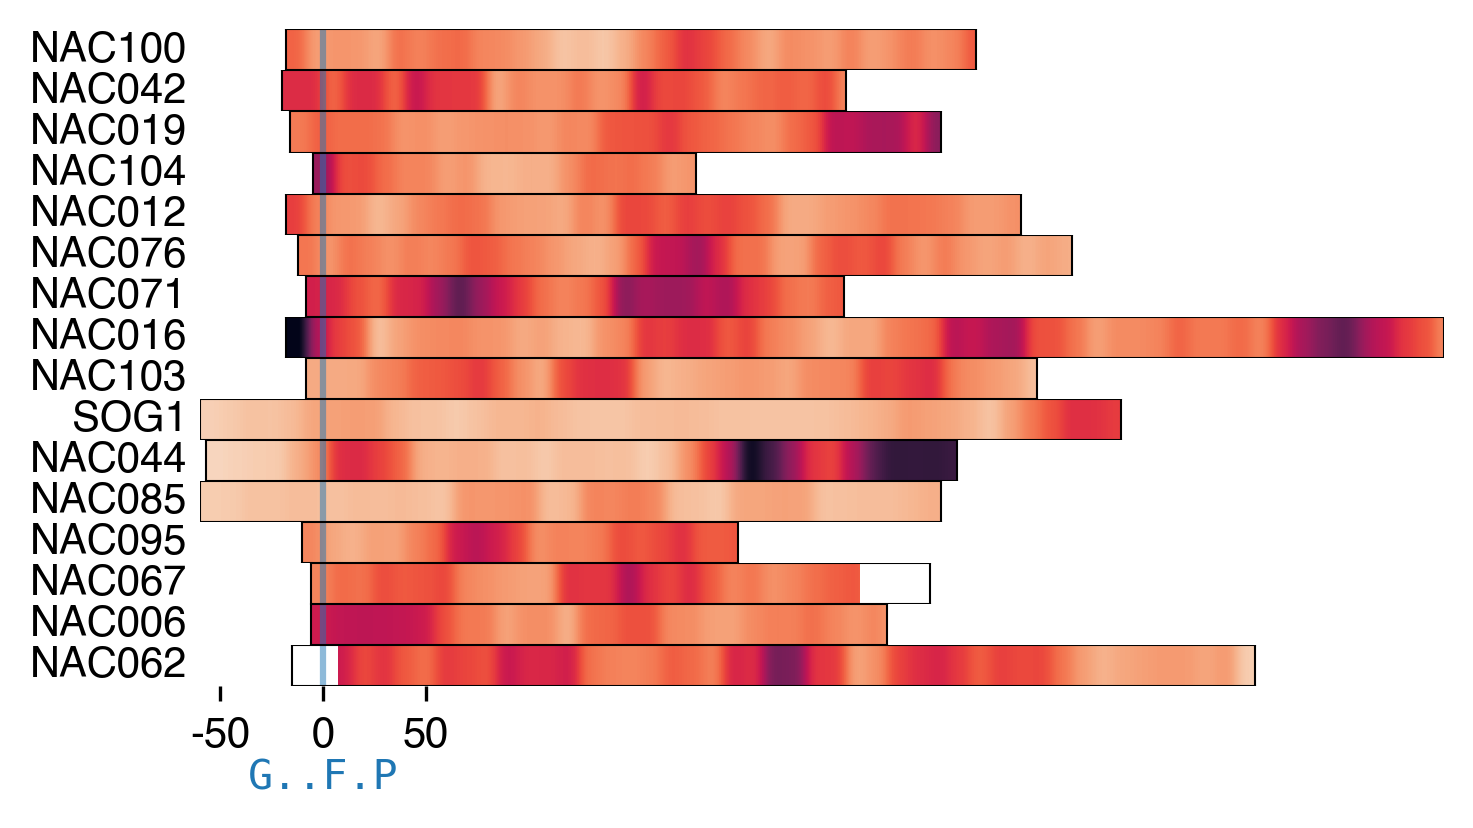

In [519]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

for name, i in zip(name_order, np.arange(len(nac_seqs))):
    plot_one_trace(name, axs[i], PS = False)
    
axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

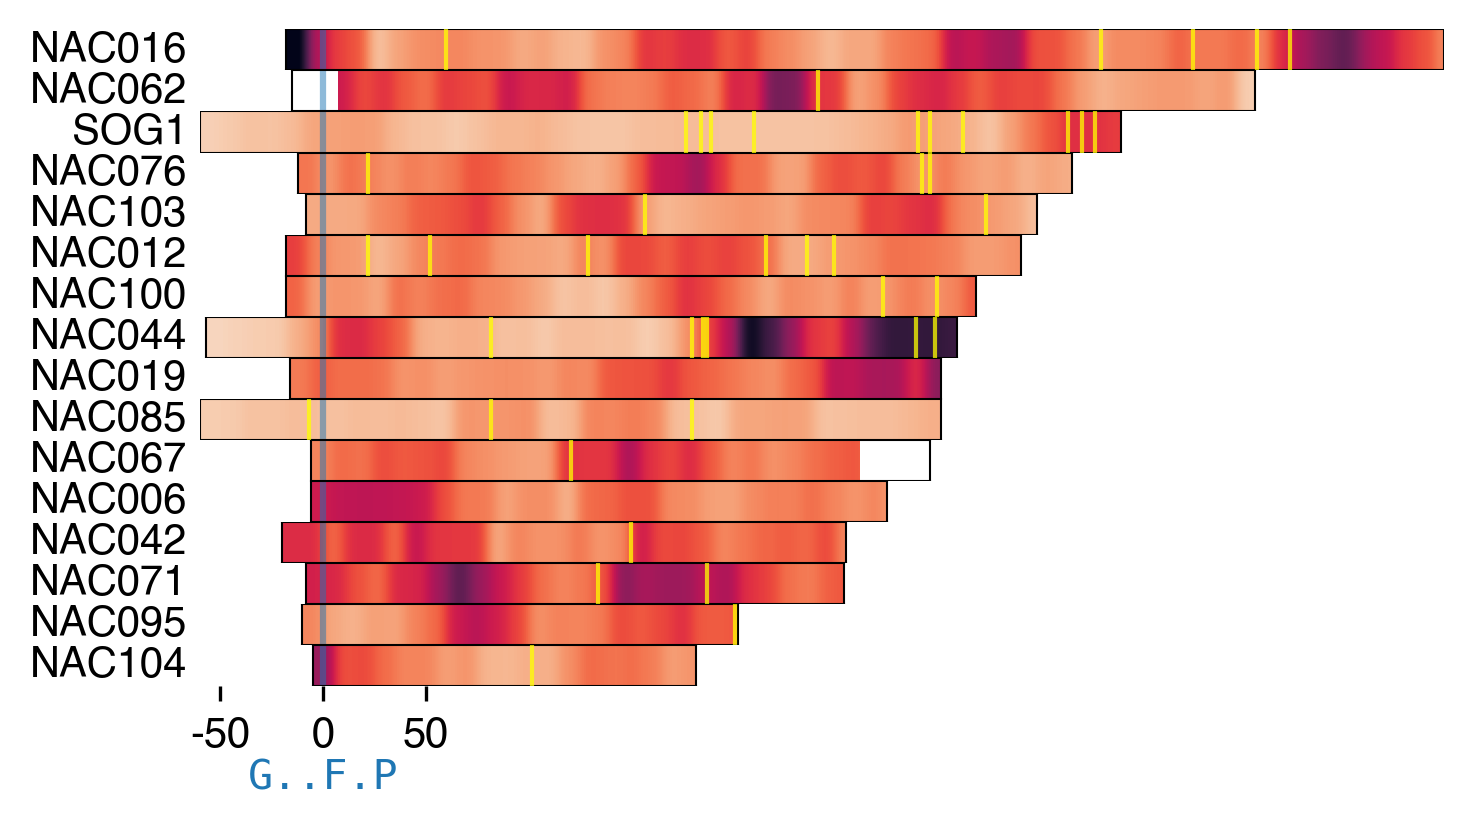

In [520]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

i = 0
for name in nac_seqs.sort_values(by = "len_past_dom", ascending = False).index:
    plot_one_trace(name, axs[i], PS = True)
    i += 1
    
axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

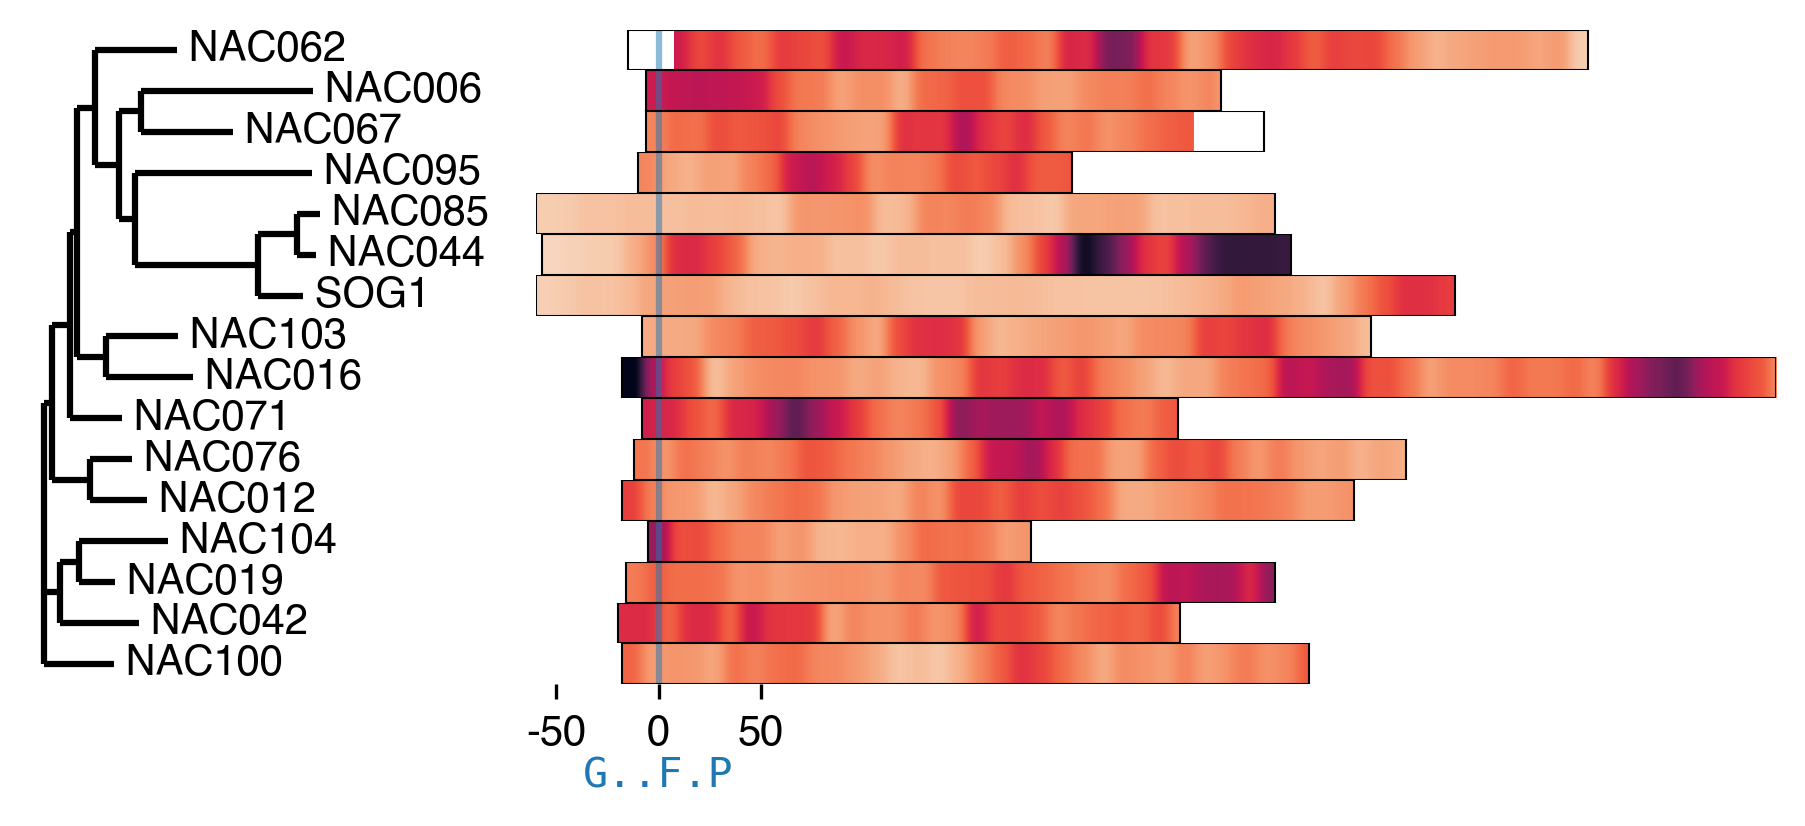

In [521]:
fig = plt.figure(figsize=(6,2.5
                         ), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [0.8, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

for i in range(len(name_order)):
    ax_i = fig.add_subplot(spec[i, 1])
    plot_one_trace(name_order[len(name_order) - i - 1], ax_i)
    ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])
        
#ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

ax_i.set_xticks([-50, 0, 50])
ax_i.set_xticklabels([-50, 0, 50])
ax_i.text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')
plt.tight_layout(pad = 0)
sns.despine(left = True, bottom = True)


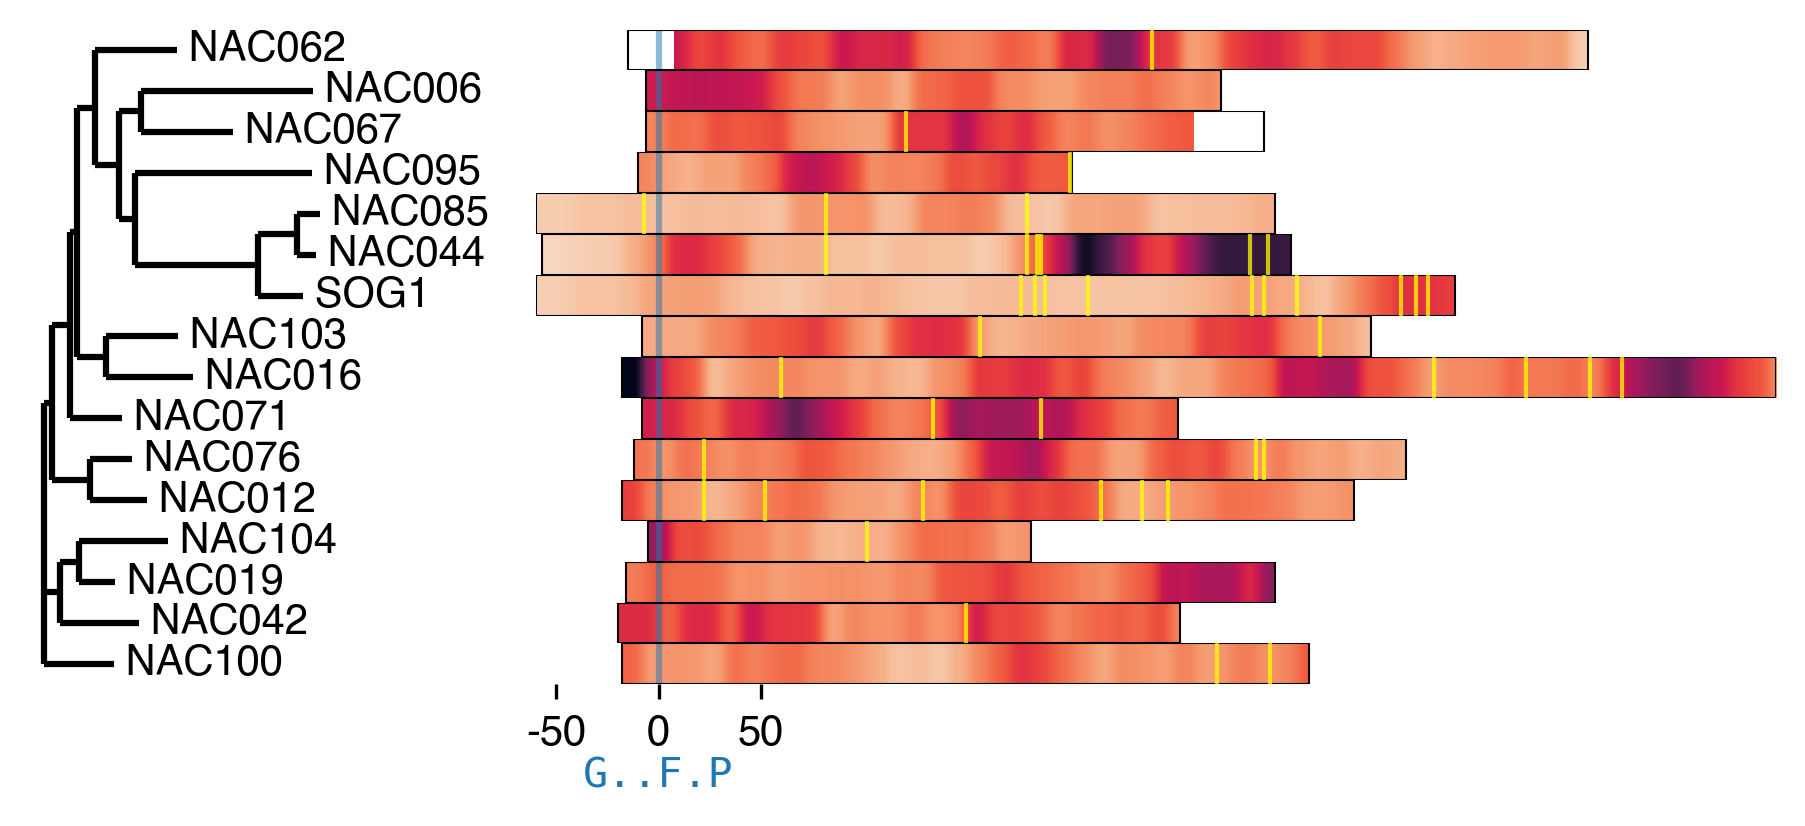

In [522]:
fig = plt.figure(figsize=(6,2.5
                         ), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [0.8, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

for i in range(len(name_order)):
    ax_i = fig.add_subplot(spec[i, 1])
    plot_one_trace(name_order[len(name_order) - i - 1], ax_i, PS = True)
    ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])
        
#ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

ax_i.set_xticks([-50, 0, 50])
ax_i.set_xticklabels([-50, 0, 50])
ax_i.text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')
plt.tight_layout(pad = 0)
sns.despine(left = True, bottom = True)

plt.savefig("../output/figures/conservation/nac_family/DBD_aligned.png", bbox_inches='tight')
